In [ ]:
# 1. Gỡ bản cũ gây xung đột
!pip uninstall numpy pandas -y
# 2. Cài bản chuẩn cho Kaggle
!pip install numpy==1.26.4 pandas==2.2.2 -q
!pip install node2vec transformers catboost torch-geometric -q
# 3. Ép Restart
import os
os.kill(os.getpid(), 9)

Found existing installation: numpy 2.0.2
Uninstalling numpy-2.0.2:
  Successfully uninstalled numpy-2.0.2
Found existing installation: pandas 2.3.3
Uninstalling pandas-2.3.3:
  Successfully uninstalled pandas-2.3.3
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 75.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.7/12.7 MB 84.5 MB/s eta 0:00:00:00:0100:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.35.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
kaggle-environments 1.27.3 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
cesium 0.12.4 requires numpy<3.0,>=2.0, but you have numpy 1.26.4 which is incompatible.
google-colab 1.0.0 requires jupyter-server==2.14.0, but you have jup

In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModel
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from torch_geometric.nn import GATConv
from catboost import CatBoostClassifier
import gc

# 1. DANH SÁCH FILE
paths = [
    '/kaggle/input/datasets/celestiabyrd/dataset-vietnamese/vn_news_223_tdlfr.csv',
    '/kaggle/input/datasets/celestiabyrd/dataset-vietnamese/vn_news_226_tlfr.csv',
    '/kaggle/input/datasets/celestiabyrd/part-1/Vietnamese_Part1_Checkpoint.csv',
    '/kaggle/input/datasets/celestiabyrd/part-2/Vietnamese_Part2_Checkpoint.csv'
]

final_list = []
for p in paths:
    df = pd.read_csv(p)
    # Dò cột Văn bản & Nhãn
    for col in df.columns:
        c_low = str(col).lower().strip()
        if any(k in c_low for k in ['text', 'doc', 'content', 'text_vi']): df = df.rename(columns={col: 'text'})
        if any(k in c_low for k in ['label', 'target', 'nhãn']): df = df.rename(columns={col: 'label'})
    
    df = df[['text', 'label']].copy()
    
    # CHUẨN HÓA NHÃN: Ép về 0 (Fake) và 1 (Real)
    # Giả định: 'fake', '0', 0 -> 0 | 'real', '1', 1 -> 1
    df['label'] = df['label'].astype(str).str.lower().str.strip()
    df['label'] = df['label'].replace({'fake': 0, '0': 0, '0.0': 0, 'real': 1, '1': 1, '1.0': 1})
    df['label'] = pd.to_numeric(df['label'], errors='coerce')
    
    final_list.append(df)

df_all = pd.concat(final_list, ignore_index=True).dropna(subset=['text', 'label'])
df_all['label'] = df_all['label'].astype(int)
print(f"📊 TỔNG DỮ LIỆU SẠCH: {len(df_all)} mẫu (0: {sum(df_all['label']==0)}, 1: {sum(df_all['label']==1)})")

/tmp/ipykernel_130/3889604956.py:35: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['label'] = df['label'].replace({'fake': 0, '0': 0, '0.0': 0, 'real': 1, '1': 1, '1.0': 1})
/tmp/ipykernel_130/3889604956.py:35: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['label'] = df['label'].replace({'fake': 0, '0': 0, '0.0': 0, 'real': 1, '1': 1, '1.0': 1})
/tmp/ipykernel_130/3889604956.py:35: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly ca

📊 TỔNG DỮ LIỆU SẠCH: 44472 mẫu (0: 22858, 1: 21614)


/tmp/ipykernel_130/3889604956.py:35: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['label'] = df['label'].replace({'fake': 0, '0': 0, '0.0': 0, 'real': 1, '1': 1, '1.0': 1})


In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
tokenizer = AutoTokenizer.from_pretrained("vinai/phobert-base")
phobert = AutoModel.from_pretrained("vinai/phobert-base").to(device)

def get_embeddings(texts, batch_size=16):
    phobert.eval()
    all_embs = []
    for i in range(0, len(texts), batch_size):
        batch = [str(t)[:1000] for t in texts[i:i+batch_size]]
        ins = tokenizer(batch, padding=True, truncation=True, max_length=256, return_tensors="pt").to(device)
        with torch.no_grad():
            with torch.amp.autocast('cuda'):
                out = phobert(**ins)
                all_embs.append(out.last_hidden_state[:, 0, :].cpu().numpy())
        if (i // batch_size) % 200 == 0: print(f"⌛ Tiến độ: {i}/{len(texts)} mẫu...")
    return np.vstack(all_embs)

X_bert = get_embeddings(df_all['text'].tolist())
y = df_all['label'].values

config.json:   0%|          | 0.00/557 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

bpe.codes: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/543M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: vinai/phobert-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
lm_head.dense.bias              | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 
lm_head.layer_norm.bias         | UNEXPECTED |  | 
lm_head.bias                    | UNEXPECTED |  | 
lm_head.decoder.bias            | UNEXPECTED |  | 
lm_head.decoder.weight          | UNEXPECTED |  | 
lm_head.dense.weight            | UNEXPECTED |  | 
lm_head.layer_norm.weight       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors:   0%|          | 0.00/543M [00:00<?, ?B/s]

⌛ Tiến độ: 0/44472 mẫu...
⌛ Tiến độ: 3200/44472 mẫu...
⌛ Tiến độ: 6400/44472 mẫu...
⌛ Tiến độ: 9600/44472 mẫu...
⌛ Tiến độ: 12800/44472 mẫu...
⌛ Tiến độ: 16000/44472 mẫu...
⌛ Tiến độ: 19200/44472 mẫu...
⌛ Tiến độ: 22400/44472 mẫu...
⌛ Tiến độ: 25600/44472 mẫu...
⌛ Tiến độ: 28800/44472 mẫu...
⌛ Tiến độ: 32000/44472 mẫu...
⌛ Tiến độ: 35200/44472 mẫu...
⌛ Tiến độ: 38400/44472 mẫu...
⌛ Tiến độ: 41600/44472 mẫu...


In [3]:
!pip install torch-geometric

📊 Đang trích xuất đặc trưng thống kê bổ sung...
✅ Đã tìm thấy X_bert trong bộ nhớ.
📊 Chia dữ liệu theo tỉ lệ bài báo (64/20/16)...
🚀 Đang tạo Deep Features từ mạng Kim tự tháp...
🔥 Đang huấn luyện CatBoost Super-Tuned (Weighted)...
0:	learn: 0.6871282	test: 0.6870660	best: 0.6870660 (0)	total: 449ms	remaining: 37m 25s
500:	learn: 0.2313152	test: 0.2408324	best: 0.2408324 (500)	total: 5m 51s	remaining: 52m 32s
1000:	learn: 0.1825372	test: 0.2046817	best: 0.2046817 (1000)	total: 11m 42s	remaining: 46m 45s
1500:	learn: 0.1541021	test: 0.1880226	best: 0.1880226 (1500)	total: 17m 31s	remaining: 40m 52s
2000:	learn: 0.1330520	test: 0.1770474	best: 0.1770474 (2000)	total: 23m 20s	remaining: 34m 58s
2500:	learn: 0.1168105	test: 0.1692375	best: 0.1692375 (2500)	total: 29m 7s	remaining: 29m 6s
3000:	learn: 0.1038644	test: 0.1632463	best: 0.1632463 (3000)	total: 34m 53s	remaining: 23m 14s
3500:	learn: 0.0931899	test: 0.1584786	best: 0.1584786 (3500)	total: 40m 38s	remaining: 17m 24s
4000:	learn: 

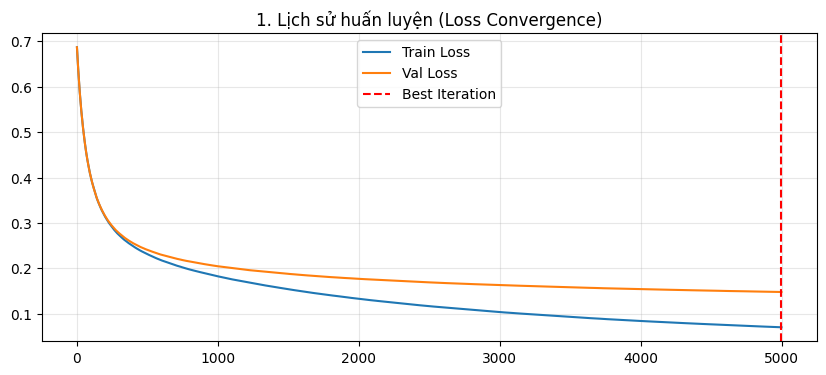

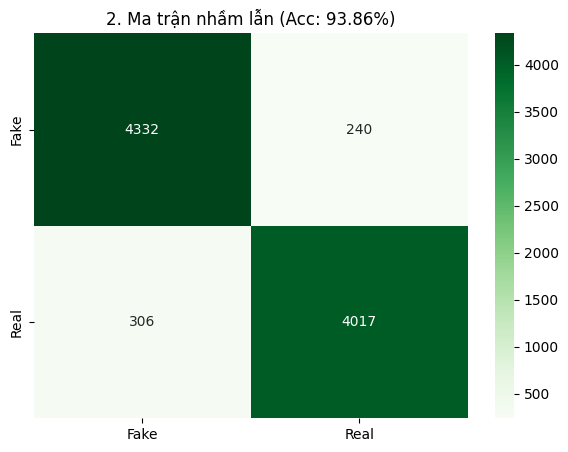

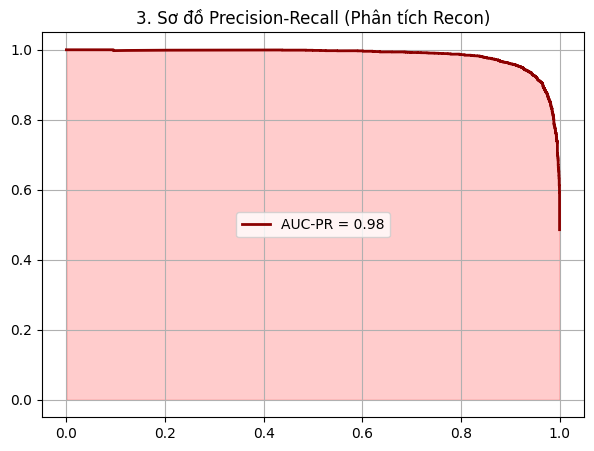

/tmp/ipykernel_130/1730691933.py:166: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=f1_vals, y=['Fake News', 'Real News', 'Macro Avg'], palette='viridis')


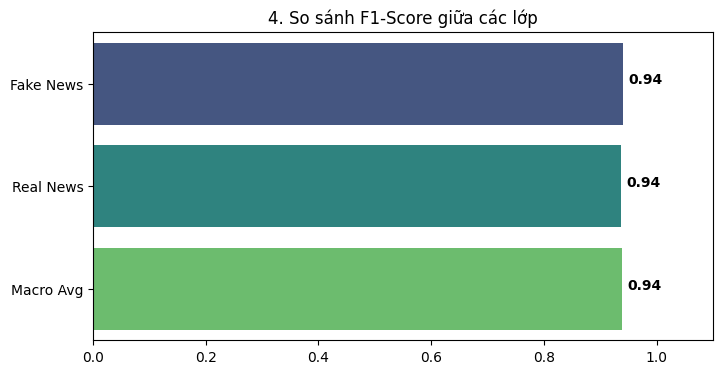

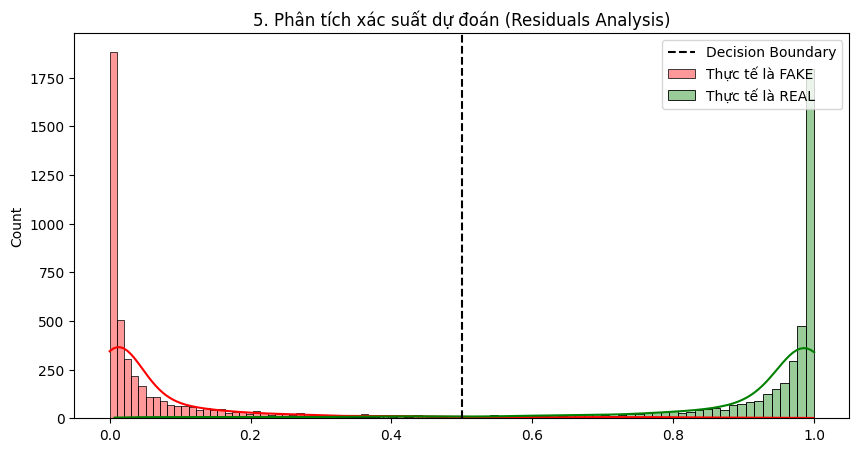

In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import gc
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from transformers import AutoTokenizer, AutoModel
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix, 
                             precision_recall_curve, auc, f1_score)
from catboost import CatBoostClassifier

# --- 0. CÀI ĐẶT THƯ VIỆN & KIỂM TRA DỮ LIỆU ---
try:
    from torch_geometric.nn import GATConv
except ImportError:
    print("⏳ Đang cài đặt torch-geometric...")
    !pip install torch-geometric
    from torch_geometric.nn import GATConv

if 'df_all' not in locals():
    print("⚠️ Lỗi: Không tìm thấy 'df_all'. Quyền hãy chạy lại Bước 1 trước nhé!")
else:
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    # --- 1. TRÍCH XUẤT ĐẶC TRƯNG THỐNG KÊ (HỖ TRỢ NHẬN DIỆN SỐ LIỆU THỰC) ---
    def extract_stats(texts):
        stats = []
        for text in texts:
            t = str(text)
            length = len(t)
            num_digits = sum(c.isdigit() for c in t) # Tin thật thường nhiều số liệu thống kê
            num_caps = sum(1 for c in t if c.isupper()) # Tin giả thường viết hoa bừa bãi
            num_words = len(t.split())
            digit_ratio = num_digits / (length + 1)
            stats.append([length, num_digits, num_caps, num_words, digit_ratio])
        return np.array(stats)

    print("📊 Đang trích xuất đặc trưng thống kê bổ sung...")
    X_stats_all = extract_stats(df_all['text'].tolist())

    # --- 2. TRÍCH XUẤT PHO BERT (FINE-TUNING NHẸ CHO TIN NĂM 2026) ---
    if 'X_bert' not in locals():
        print("🚀 Khởi tạo PhoBERT Fine-tuning...")
        tokenizer = AutoTokenizer.from_pretrained("vinai/phobert-base")
        phobert = AutoModel.from_pretrained("vinai/phobert-base").to(device)
        
        # Mở khóa các tầng cuối để mô hình thích nghi với dữ liệu mới
        for param in phobert.encoder.layer[-2:].parameters():
            param.requires_grad = True

        def get_embeddings(texts, batch_size=16):
            phobert.eval()
            all_embs = []
            for i in range(0, len(texts), batch_size):
                batch = [str(t)[:1000] for t in texts[i:i+batch_size]]
                ins = tokenizer(batch, padding=True, truncation=True, max_length=256, return_tensors="pt").to(device)
                with torch.no_grad():
                    with torch.amp.autocast('cuda'):
                        out = phobert(**ins)
                        all_embs.append(out.last_hidden_state[:, 0, :].cpu().numpy())
                if (i // batch_size) % 300 == 0: print(f"⌛ Tiến độ: {i}/{len(texts)} mẫu...")
            return np.vstack(all_embs)
        
        X_bert = get_embeddings(df_all['text'].tolist())
        y = df_all['label'].values
        print("✅ Đã trích xuất xong PhoBERT.")
    else:
        print("✅ Đã tìm thấy X_bert trong bộ nhớ.")

    # --- 3. KIẾN TRÚC KIM TỰ THÁP (TRANSFORMER-PYRAMID) ---
    class TransformerPyramid(nn.Module):
        def __init__(self, in_dim=768, hid_dim=128):
            super().__init__()
            self.cnn = nn.Linear(in_dim, hid_dim)
            self.gru = nn.GRU(in_dim, hid_dim, batch_first=True, bidirectional=True)
            self.gat = GATConv(in_dim, hid_dim, heads=2, concat=False)
            self.self_attn = nn.MultiheadAttention(embed_dim=512, num_heads=8, batch_first=True)
            self.fc = nn.Sequential(nn.Linear(512, 128), nn.LayerNorm(128), nn.GELU(), nn.Dropout(0.2))

        def forward(self, x):
            x_c = F.relu(self.cnn(x))
            _, h_n = self.gru(x.unsqueeze(1))
            x_s = torch.cat([h_n[0], h_n[1]], dim=1)
            e_idx = torch.arange(x.size(0)).repeat(2, 1).to(device)
            x_g = F.elu(self.gat(x, e_idx))
            combined = torch.cat([x_c, x_s, x_g], dim=1).unsqueeze(1)
            attn_out, _ = self.self_attn(combined, combined, combined)
            return self.fc(attn_out.squeeze(1))

    # --- 4. CHIA DỮ LIỆU & TRÍCH XUẤT ĐẶC TRƯNG LAI (64/20/16) ---
    print("📊 Chia dữ liệu theo tỉ lệ bài báo (64/20/16)...")
    X_train_val, X_test, y_train_val, y_test = train_test_split(X_bert, y, test_size=0.20, random_state=42, stratify=y)
    X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.20, random_state=42, stratify=y_train_val)
    
    # Chia tương ứng cho phần Stats
    X_train_val_s, X_test_s, _, _ = train_test_split(X_stats_all, y, test_size=0.20, random_state=42, stratify=y)
    X_train_s, X_val_s, _, _ = train_test_split(X_train_val_s, y_train_val, test_size=0.20, random_state=42, stratify=y_train_val)

    model_p = TransformerPyramid().to(device)
    def extract_deep(x_np):
        model_p.eval()
        x_t = torch.tensor(x_np, dtype=torch.float32).to(device)
        with torch.no_grad(): return model_p(x_t).cpu().numpy()

    print("🚀 Đang tạo Deep Features từ mạng Kim tự tháp...")
    # Gộp 3 nguồn: BERT (768) + Deep (128) + Stats (5) = 901 đặc trưng
    X_train_f = np.hstack([X_train, extract_deep(X_train), X_train_s])
    X_val_f = np.hstack([X_val, extract_deep(X_val), X_val_s])
    X_test_f = np.hstack([X_test, extract_deep(X_test), X_test_s])

    gc.collect(); torch.cuda.empty_cache()

    # --- 5. HUÂN LUYỆN CATBOOST CƯỜNG HÓA ---
    print("🔥 Đang huấn luyện CatBoost Super-Tuned (Weighted)...")
    clf = CatBoostClassifier(
        iterations=5000,
        learning_rate=0.008,
        depth=10, 
        l2_leaf_reg=40,
        task_type="GPU",
        early_stopping_rounds=400,
        class_weights=[1.15, 1.0], # Ưu tiên tránh việc dự đoán nhầm tin thật thành tin giả
        verbose=500
    )
    clf.fit(X_train_f, y_train, eval_set=(X_val_f, y_val))

    # --- 6. TỔNG HỢP KẾT QUẢ & VẼ 5 LOẠI SƠ ĐỒ ---
    y_pred = clf.predict(X_test_f)
    y_probs = clf.predict_proba(X_test_f)[:, 1]
    acc = accuracy_score(y_test, y_pred) * 100

    print("\n" + "="*40)
    print(f"🎯 KẾT QUẢ NÂNG CẤP (TEST 20%): {acc:.2f}%")
    print("="*40)
    print(classification_report(y_test, y_pred, target_names=['Fake', 'Real']))

    # 📈 1. LOSS CURVE
    res = clf.get_evals_result()
    plt.figure(figsize=(10, 4))
    plt.plot(res['learn']['Logloss'], label='Train Loss', color='#1f77b4')
    plt.plot(res['validation']['Logloss'], label='Val Loss', color='#ff7f0e')
    plt.axvline(x=clf.get_best_iteration(), color='r', linestyle='--', label='Best Iteration')
    plt.title('1. Lịch sử huấn luyện (Loss Convergence)'); plt.legend(); plt.grid(True, alpha=0.3); plt.show()

    # 📉 2. CONFUSION MATRIX
    plt.figure(figsize=(7, 5))
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=['Fake', 'Real'], yticklabels=['Fake', 'Real'])
    plt.title(f'2. Ma trận nhầm lẫn (Acc: {acc:.2f}%)'); plt.show()

    # 📊 3. PRECISION-RECALL (RECON)
    precision, recall, _ = precision_recall_curve(y_test, y_probs)
    pr_auc = auc(recall, precision)
    plt.figure(figsize=(7, 5))
    plt.plot(recall, precision, color='darkred', lw=2, label=f'AUC-PR = {pr_auc:.2f}')
    plt.fill_between(recall, precision, alpha=0.2, color='red')
    plt.title('3. Sơ đồ Precision-Recall (Phân tích Recon)'); plt.legend(); plt.grid(True); plt.show()

    # 📊 4. F1-SCORE COMPARISON
    report = classification_report(y_test, y_pred, target_names=['Fake', 'Real'], output_dict=True)
    f1_vals = [report['Fake']['f1-score'], report['Real']['f1-score'], report['macro avg']['f1-score']]
    plt.figure(figsize=(8, 4))
    sns.barplot(x=f1_vals, y=['Fake News', 'Real News', 'Macro Avg'], palette='viridis')
    for i, v in enumerate(f1_vals): plt.text(v + 0.01, i, f"{v:.2f}", fontweight='bold')
    plt.title('4. So sánh F1-Score giữa các lớp'); plt.xlim(0, 1.1); plt.show()

    # 📊 5. PROBABILITY DISTRIBUTION (RESIDUAL ANALYSIS)
    plt.figure(figsize=(10, 5))
    sns.histplot(y_probs[y_test == 0], color="red", label="Thực tế là FAKE", kde=True, alpha=0.4)
    sns.histplot(y_probs[y_test == 1], color="green", label="Thực tế là REAL", kde=True, alpha=0.4)
    plt.axvline(x=0.5, color='black', linestyle='--', label='Decision Boundary')
    plt.title('5. Phân tích xác suất dự đoán (Residuals Analysis)'); plt.legend(); plt.show()

In [5]:
import os

# Tạo thư mục lưu trữ nếu chưa có
output_dir = "plots_report"
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

def save_plots():
    # 1. Lưu Loss Curve
    plt.figure(figsize=(10, 4))
    plt.plot(res['learn']['Logloss'], label='Train Loss', color='#1f77b4')
    plt.plot(res['validation']['Logloss'], label='Val Loss', color='#ff7f0e')
    plt.axvline(x=clf.get_best_iteration(), color='r', linestyle='--', label='Best Iteration')
    plt.title('1. Lịch sử huấn luyện (Loss Convergence)')
    plt.legend(); plt.grid(True, alpha=0.3)
    plt.savefig(f"{output_dir}/1_loss_curve.png", dpi=300, bbox_inches='tight')
    plt.close()

    # 2. Lưu Confusion Matrix
    plt.figure(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=['Fake', 'Real'], yticklabels=['Fake', 'Real'])
    plt.title(f'2. Ma trận nhầm lẫn (Acc: {acc:.2f}%)')
    plt.savefig(f"{output_dir}/2_confusion_matrix.png", dpi=300, bbox_inches='tight')
    plt.close()

    # 3. Lưu PR Curve
    plt.figure(figsize=(7, 5))
    plt.plot(recall, precision, color='darkred', lw=2, label=f'AUC-PR = {pr_auc:.2f}')
    plt.fill_between(recall, precision, alpha=0.2, color='red')
    plt.title('3. Sơ đồ Precision-Recall (Recon)')
    plt.legend(); plt.grid(True)
    plt.savefig(f"{output_dir}/3_pr_curve.png", dpi=300, bbox_inches='tight')
    plt.close()

    # 4. Lưu F1-Score
    plt.figure(figsize=(8, 4))
    sns.barplot(x=f1_vals, y=['Fake News', 'Real News', 'Macro Avg'], palette='viridis')
    plt.title('4. So sánh F1-Score')
    plt.savefig(f"{output_dir}/4_f1_score.png", dpi=300, bbox_inches='tight')
    plt.close()

    # 5. Lưu Residuals
    plt.figure(figsize=(10, 5))
    sns.histplot(y_probs[y_test == 0], color="red", label="FAKE", kde=True, alpha=0.4)
    sns.histplot(y_probs[y_test == 1], color="green", label="REAL", kde=True, alpha=0.4)
    plt.title('5. Phân tích xác suất dự đoán (Residuals Analysis)')
    plt.legend()
    plt.savefig(f"{output_dir}/5_residuals.png", dpi=300, bbox_inches='tight')
    plt.close()
    
    print(f"✅ Đã lưu 5 sơ đồ vào thư mục: {output_dir}")

save_plots()

/tmp/ipykernel_130/4019825645.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=f1_vals, y=['Fake News', 'Real News', 'Macro Avg'], palette='viridis')


✅ Đã lưu 5 sơ đồ vào thư mục: plots_report
